In [33]:
#import
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('train:', train.shape, '| test:', test.shape)

train: (29304, 16) | test: (3257, 15)


In [34]:
#EDA
train.head(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3331,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States,>50K
1,19749,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
2,1157,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States,<=50K
3,693,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States,>50K
4,12522,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States,<=50K


In [35]:
train.shape

(29304, 16)

In [36]:
train.tail(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
29299,15999,28.0,Private,47168,10th,6,Never-married,Machine-op-inspct,Own-child,White,Female,0,0,40.0,United-States,<=50K
29300,21604,44.0,Local-gov,231793,Doctorate,16,Married-spouse-absent,Prof-specialty,Unmarried,White,Female,0,0,38.0,United-States,<=50K
29301,26839,41.0,Local-gov,201435,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40.0,United-States,<=50K
29302,16681,43.0,Private,137722,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,<=50K
29303,16069,22.0,Private,406978,Bachelors,13,Never-married,Exec-managerial,Other-relative,White,Female,0,0,40.0,United-States,<=50K


In [37]:
train.sample(5)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
28388,13287,56.0,Private,285730,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,66.0,United-States,<=50K
21438,27872,46.0,Self-emp-inc,125892,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,50.0,United-States,>50K
16370,26233,43.0,Local-gov,94937,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,28.0,United-States,<=50K
22544,14632,24.0,Private,325744,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
10276,21088,63.0,Private,64544,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,40.0,United-States,>50K


In [38]:
#데이터 크기 확인
train.shape, test.shape

((29304, 16), (3257, 15))

In [39]:
#자료형 타입 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29304 non-null  int64  
 1   age             29292 non-null  float64
 2   workclass       27642 non-null  object 
 3   fnlwgt          29304 non-null  int64  
 4   education       29304 non-null  object 
 5   education.num   29304 non-null  int64  
 6   marital.status  29304 non-null  object 
 7   occupation      27636 non-null  object 
 8   relationship    29304 non-null  object 
 9   race            29304 non-null  object 
 10  sex             29304 non-null  object 
 11  capital.gain    29304 non-null  int64  
 12  capital.loss    29304 non-null  int64  
 13  hours.per.week  29291 non-null  float64
 14  native.country  28767 non-null  object 
 15  income          29304 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 3.6+ MB


/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

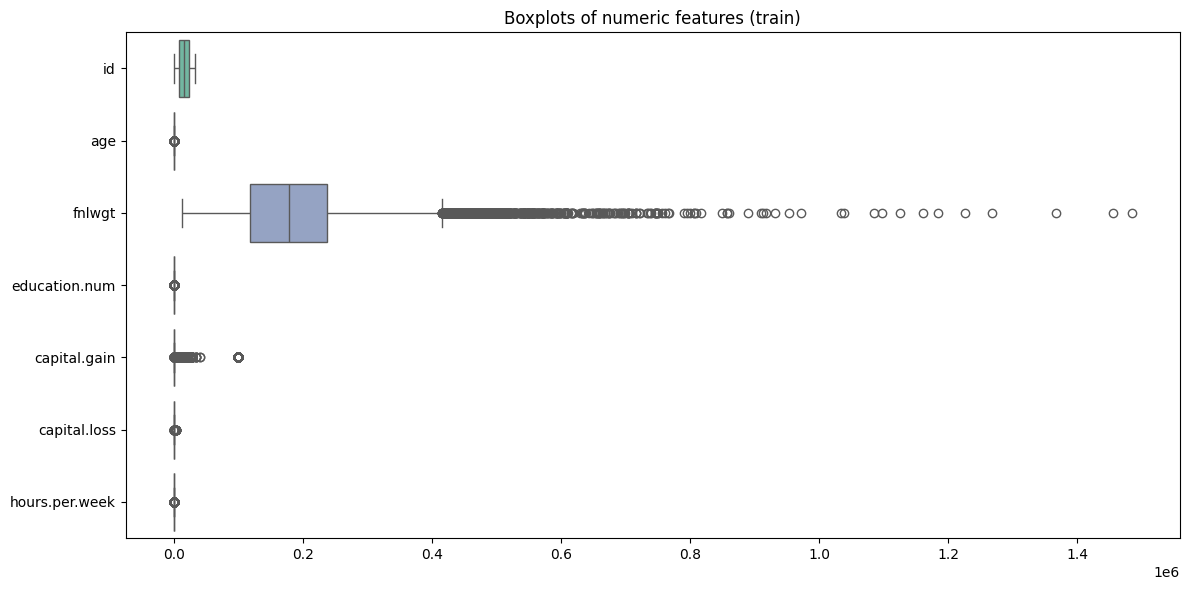

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 컬럼만 추출
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=train[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplots of numeric features (train)")
plt.tight_layout()
plt.show()

In [16]:
#데이터 전처리

In [41]:
num_cols = ['age', 'hours.per.week'] # 수치형 데이터
cat_cols = ['workclass', 'occupation', 'native.country'] # 범주형 데이터
for c in num_cols:
    m = train[c].median()            # train 기준 중앙값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
for c in cat_cols:
    m = train[c].mode()[0]           # train 기준 최빈값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
print('남은 결측치:', train.isnull().sum().sum(), test.isnull().sum().sum())

남은 결측치: 0 0


In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29304 non-null  int64  
 1   age             29304 non-null  float64
 2   workclass       29304 non-null  object 
 3   fnlwgt          29304 non-null  int64  
 4   education       29304 non-null  object 
 5   education.num   29304 non-null  int64  
 6   marital.status  29304 non-null  object 
 7   occupation      29304 non-null  object 
 8   relationship    29304 non-null  object 
 9   race            29304 non-null  object 
 10  sex             29304 non-null  object 
 11  capital.gain    29304 non-null  int64  
 12  capital.loss    29304 non-null  int64  
 13  hours.per.week  29304 non-null  float64
 14  native.country  29304 non-null  object 
 15  income          29304 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 3.6+ MB


In [43]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3257 non-null   int64  
 1   age             3257 non-null   float64
 2   workclass       3257 non-null   object 
 3   fnlwgt          3257 non-null   int64  
 4   education       3257 non-null   object 
 5   education.num   3257 non-null   int64  
 6   marital.status  3257 non-null   object 
 7   occupation      3257 non-null   object 
 8   relationship    3257 non-null   object 
 9   race            3257 non-null   object 
 10  sex             3257 non-null   object 
 11  capital.gain    3257 non-null   int64  
 12  capital.loss    3257 non-null   int64  
 13  hours.per.week  3257 non-null   float64
 14  native.country  3257 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 381.8+ KB


In [21]:
# train 에서 y값 분리

In [44]:
train.head()

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3331,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States,>50K
1,19749,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
2,1157,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States,<=50K
3,693,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States,>50K
4,12522,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States,<=50K


In [45]:
y = train['income'].map({'<=50K': 0, '>50K': 1})   # 문자 → 0/1
y

0        1
1        0
2        0
3        1
4        0
        ..
29299    0
29300    0
29301    0
29302    0
29303    0
Name: income, Length: 29304, dtype: int64

In [46]:
train.shape

(29304, 16)

In [47]:
#train = train.drop(columns=['id', 'income'])
train.shape

(29304, 16)

In [48]:
test.shape

(3257, 15)

In [49]:
test_id = test['id']                                # 제출용 보관
test = test.drop(columns=['id'])

In [50]:
test.shape

(3257, 14)

In [51]:
all_df = pd.concat([train, test], axis=0)           # 합쳐서 인코딩
all_oh = pd.get_dummies(all_df)

In [31]:
all_oh

,id,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_<=50K,income_>50K
0,3331.0,34.0,177331,10,4386,0,40.0,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,19749.0,58.0,290661,9,0,0,40.0,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,1157.0,48.0,125933,10,0,1669,38.0,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,693.0,58.0,100313,10,0,1902,40.0,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,12522.0,41.0,195661,10,0,0,54.0,False,False,False,...,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,NaN,28.0,202558,10,0,0,40.0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3253,NaN,52.0,94391,9,0,0,40.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3254,NaN,25.0,109526,9,0,0,38.0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3255,NaN,36.0,242713,9,0,0,40.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [52]:
X = all_oh.iloc[:len(train)]                        # 다시 train 부분
X_test = all_oh.iloc[len(train):]                   # test 부분
print('인코딩 후 컬럼 수:', X.shape[1])

인코딩 후 컬럼 수: 108


In [53]:
# 검증 데이터 분할
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
print(X_tr.shape, X_val.shape)

(23443, 108) (5861, 108)


In [54]:
# 데이터 학습
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_tr, y_tr)

RandomForestClassifier(random_state=0)

In [59]:
# 모델 검증 지표
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
#pred = rf.predict(X_val)
print(pred)
proba = rf.predict_proba(X_val)[:, 1]   # 1(>50K)일 확률 열만 (2차원 슬라이싱)
print(proba)
#print('정확도 :', round(accuracy_score(y_val, pred), 4))
#print('ROC-AUC:', round(roc_auc_score(y_val, proba), 4))
#print(classification_report(y_val, pred))

[1 0 1 ... 0 0 0]
[0.58 0.02 0.91 ... 0.   0.   0.  ]


In [55]:
rf.predict_proba(X_test)

array([[0.46, 0.54],
       [0.52, 0.48],
       [0.42, 0.58],
       ...,
       [0.45, 0.55],
       [0.49, 0.51],
       [0.54, 0.46]], shape=(3257, 2))

In [56]:
# test 예측 & 제출 파일
test_proba = rf.predict_proba(X_test)[:, 1]
submit = pd.DataFrame({'id': test_id, 'income': test_proba})
submit.to_csv('submission.csv', index=False)   # index=False 필수
submit.head()

,id,income
0,11574,0.54
1,15847,0.48
2,17655,0.58
3,19790,0.55
4,31812,0.55


In [74]:
# 1. income을 먼저 분리
y = train['income'].map({'<=50K': 0, '>50K': 1})
train_features = train.drop(columns=['income'])   # income 뺀 train

# 2. income이 빠진 상태로 합쳐서 인코딩
all_df = pd.concat([train_features, test], axis=0)
all_oh = pd.get_dummies(all_df)

# 3. 다시 나누기
X = all_oh.iloc[:len(train)]
X_test = all_oh.iloc[len(train):]

print('인코딩 후 컬럼 수:', X.shape[1])
print(X.columns.tolist())   # income 관련 컬럼이 없는지 최종 확인

from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
print(X_tr.shape, X_val.shape)

# ★ 확인 습관: 새로 나눈 X_tr에도 income이 없는지 재확인
print([c for c in X_tr.columns if 'income' in c])   # 빈 리스트([])가 나와야 정상

# ── 1. RandomForest 학습 ──
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=0)
rf.fit(X_tr, y_tr)

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

pred_rf = rf.predict(X_val)
proba_rf = rf.predict_proba(X_val)[:, 1]

print('[RandomForest]')
print('정확도 :', round(accuracy_score(y_val, pred_rf), 4))
print('ROC-AUC:', round(roc_auc_score(y_val, proba_rf), 4))
print(classification_report(y_val, pred_rf))


# ── 2. LightGBM 학습 ──
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(random_state=0, verbose=-1)
lgbm.fit(X_tr, y_tr)   # ← fit 빠뜨리면 안 됨!

pred_lgb = lgbm.predict(X_val)
proba_lgb = lgbm.predict_proba(X_val)[:, 1]

print('[LightGBM]')
print('정확도 :', round(accuracy_score(y_val, pred_lgb), 4))
print('ROC-AUC:', round(roc_auc_score(y_val, proba_lgb), 4))
print(classification_report(y_val, pred_lgb))

인코딩 후 컬럼 수: 106
['id', 'age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital.status_Divorced', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'marital.status_Married-spouse-absent', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Fa